In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv(r'heart.csv')
df = df.drop(columns=['thal','ca'])

In [7]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
0,63,1,3,145,233,1,0,150,0,2.3,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,1
2,41,0,1,130,204,0,0,172,0,1.4,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,1


### Outlier Detection & Extreme Values

Box Plots for Continous variables: These continuous variables are most likely to have outliers. Box plots clearly show outliers as points beyond the whiskers.

Scatter Plot for chol vs trestbps: Medical values like cholesterol and blood pressure can have measurement errors or extreme cases that need investigation

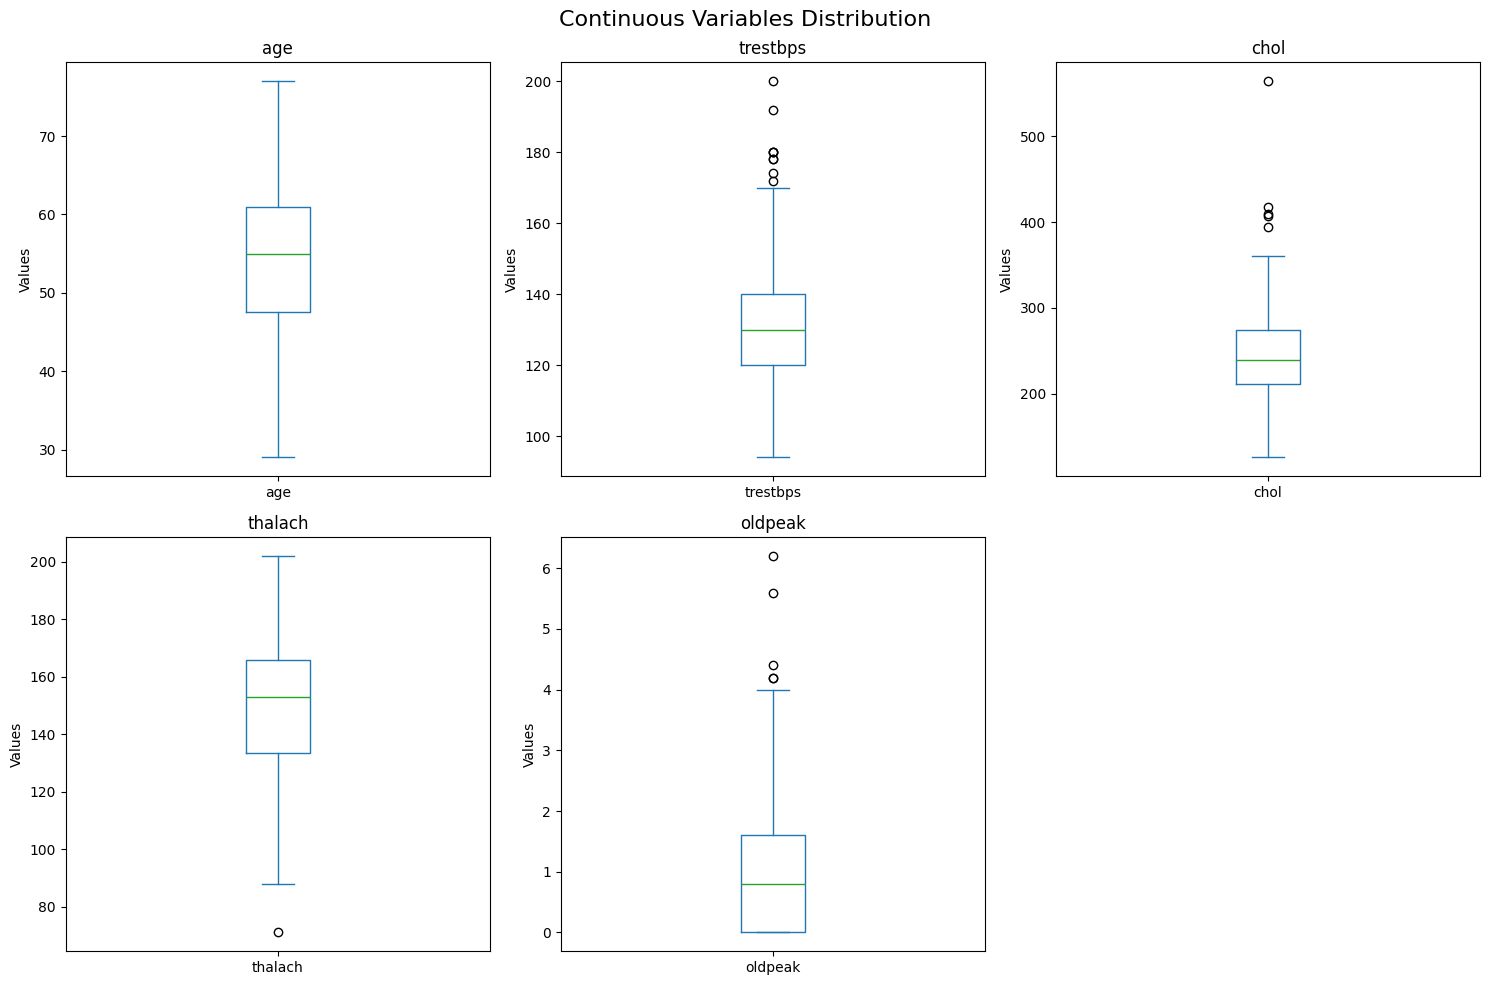

In [8]:
continuous_var = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Continuous Variables Distribution', fontsize=16)

axes_flat = axes.flatten()

for i, column in enumerate(continuous_var):
    if i < len(axes_flat):
        df[column].plot(kind='box', ax=axes_flat[i])
        axes_flat[i].set_title(f'{column}')
        axes_flat[i].set_ylabel('Values')

# Hide empty subplot
axes_flat[5].set_visible(False)

plt.tight_layout()
plt.show()



Text(0, 0.5, 'Values')

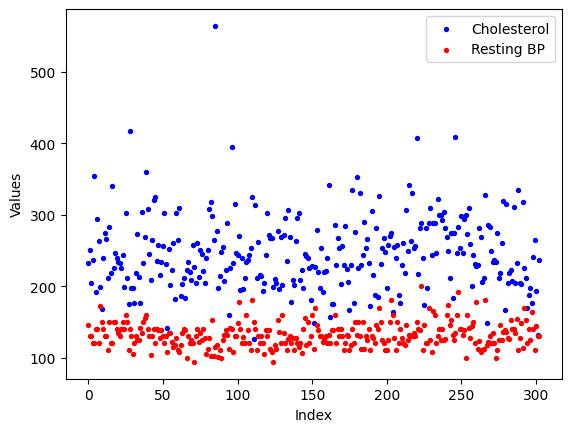

In [9]:
plt.scatter(df.index, df['chol'], s=8, c='b', label='Cholesterol')
plt.scatter(df.index, df['trestbps'], s=8, c='r', label='Resting BP')
plt.legend()
plt.xlabel('Index')
plt.ylabel('Values')

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (3,) and arg 1 with shape (2,).

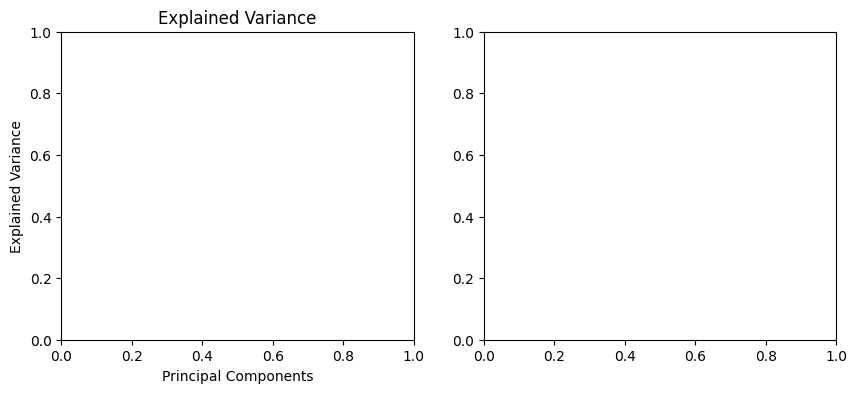

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

N = 1000
M = 3
K = 2
# Step 1: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Step 2: Apply PCA
pca = PCA(n_components=2)  # or however many components you want
X = pca.fit_transform(X_scaled)

# Explained variance plot
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].set_title('Explained Variance')
axs[0].set_xlabel('Principal Components')
axs[0].set_ylabel('Explained Variance')

# Bar plot for explained variance
# YOUR CODE HERE
explained_variance = pca.fit(X).explained_variance_
axs[0].bar(range(1, M + 1), explained_variance, color='lightblue', edgecolor='black')

# Accumulated explained variance plot
axs[1].set_title('Accumulated fraction of explained variance')
axs[1].set_xlabel('Principal Components')
axs[1].set_ylabel('Accumulated Explained Variance')

# Line plot for accumulated explained variance
# YOUR CODE HERE
accumulated_variance = np.cumsum(explained_variance) / np.sum(explained_variance)
axs[1].plot(range(1, M + 1), accumulated_variance, marker='o', color='lightblue')
axs[1].set_ylim(0, 1.05)
# Horizontal line at 95% explained variance
axs[1].axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance')
axs[1].legend()
axs[1].axhline(y=0.90, color='g', linestyle='--', label='90% Explained Variance')
axs[1].legend()
plt.show()